Data Understanding + Data Quality Checks + Stratified Split

0) Imports + Settings

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

1) Load the Dataset

In [ ]:
DATA_PATH = "/content/fraud_oracle.csv"
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(15420, 33)


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


2) Basic Dataset Overview

In [ ]:
print("Rows, Cols:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.value_counts())
display(df.dtypes)

print("\nSample rows:")
display(df.head(3))

Rows, Cols: (15420, 33)

Column names:
['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex', 'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'FraudFound_P', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year', 'BasePolicy']

Data types:


,count
object,24
int64,9


,0
Month,object
WeekOfMonth,int64
DayOfWeek,object
Make,object
AccidentArea,object
DayOfWeekClaimed,object
MonthClaimed,object
WeekOfMonthClaimed,int64
Sex,object
MaritalStatus,object



Sample rows:


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision


3) Target Column Check + Class Imbalance

In [ ]:
target_col_candidates = ["FraudFound_P", "FraudFound_P ", "fraud", "target", "FraudFoundP"]
found = [c for c in df.columns if c in target_col_candidates]

print("Target candidates found:", found)

Target candidates found: ['FraudFound_P']


Class counts:
 FraudFound_P
0    14497
1      923
Name: count, dtype: int64

Class proportions:
 FraudFound_P
0    0.940143
1    0.059857
Name: proportion, dtype: float64


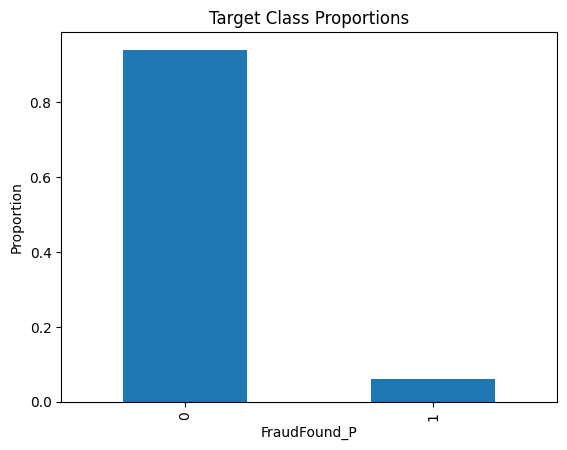

In [ ]:
TARGET = "FraudFound_P"  # change if your dataset uses a slightly different name

# Distribution
counts = df[TARGET].value_counts(dropna=False)
props = df[TARGET].value_counts(normalize=True, dropna=False)

print("Class counts:\n", counts)
print("\nClass proportions:\n", props)

# Quick plot
plt.figure()
props.sort_index().plot(kind="bar")
plt.title("Target Class Proportions")
plt.xlabel(TARGET)
plt.ylabel("Proportion")
plt.show()

4) Missing Values + Duplicate Rows

In [ ]:
# Missing values
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
})
display(missing_summary.head(20))

# Duplicate rows
dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)

,missing_count,missing_pct
Month,0,0.0
WeekOfMonth,0,0.0
DayOfWeek,0,0.0
Make,0,0.0
AccidentArea,0,0.0
DayOfWeekClaimed,0,0.0
MonthClaimed,0,0.0
WeekOfMonthClaimed,0,0.0
Sex,0,0.0
MaritalStatus,0,0.0


Duplicate rows: 0


5) Basic Integrity Checks (Quick Sanity)

In [ ]:
# Check unique values of target
print("Unique target values:", sorted(df[TARGET].dropna().unique()))

# Check for obvious ID-like columns (high cardinality)
high_card = []
for c in df.columns:
    if df[c].nunique(dropna=False) > 0.9 * len(df):
        high_card.append(c)

print("Potential ID/high-cardinality columns:", high_card)

Unique target values: [np.int64(0), np.int64(1)]
Potential ID/high-cardinality columns: ['PolicyNumber']


6) Quick Feature Type Split (Categorical vs Numeric)

In [ ]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Num cols:", len(num_cols))
print("Cat cols:", len(cat_cols))

print("\nExample numeric cols:", num_cols[:10])
print("Example categorical cols:", cat_cols[:10])

Num cols: 8
Cat cols: 24

Example numeric cols: ['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Year']
Example categorical cols: ['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType']


7) Stratified Train/Val/Test Split

In [ ]:
# First split: train vs temp (80/20)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Second split: val vs test (10/10 from total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

print("\nFraud rate (train/val/test):")
print("Train:", y_train.mean())
print("Val:  ", y_val.mean())
print("Test: ", y_test.mean())

Train: (12336, 32) (12336,)
Val:   (1542, 32) (1542,)
Test:  (1542, 32) (1542,)

Fraud rate (train/val/test):
Train: 0.05982490272373541
Val:   0.06031128404669261
Test:  0.05966277561608301


Preprocessing Pipeline + Logistic Regression Baseline + Evaluation

1. Imports

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import numpy as np

2. Identify Feature Types (from TRAIN only)

In [ ]:
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

print("\nExample numeric cols:", num_cols[:10])
print("Example categorical cols:", cat_cols[:10])

Numeric columns: 8
Categorical columns: 24

Example numeric cols: ['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Year']
Example categorical cols: ['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType']


3. Build Preprocessing Pipelines

In [ ]:
# Numeric pipeline: median imputation + scaling
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline: fill missing + one-hot
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

4. Build Logistic Regression Pipeline

In [ ]:
clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=5000,
        solver="saga",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

clf

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['WeekOfMonth',
                                                   'WeekOfMonthClaimed', 'Age',
                                                   'PolicyNumber', 'RepNumber',
                                                   'Deductible', 'DriverRating',
                                                   'Year']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='con...
                                                   'VehicleCategory',
                                                   'VehiclePrice',
                                                   'Days_Policy_Accident',
                                                   'Days_Policy_Claim',
                                                   'PastNumberOfClaims',
                                                   'AgeOfVehicle',
                                                   'AgeOfPolicyHolder',
                                                   'PoliceReportFiled',
                                                   'WitnessPresent',
                                                   'AgentType',
                                                   'NumberOfSuppliments',
                                                   'AddressChange_Claim',
                                                   'NumberOfCars',
                                                   'BasePolicy'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=5000,
                                    n_jobs=-1, random_state=42,
                                    solver='saga'))])

5. Train Model

In [ ]:
clf.fit(X_train, y_train)
print("Model trained ✅")

Model trained ✅


6. PR-AUC (Primary Metric)

In [ ]:
y_val_prob = clf.predict_proba(X_val)[:, 1]

pr_auc = average_precision_score(y_val, y_val_prob)
print(f"Validation PR-AUC: {pr_auc:.4f}")

Validation PR-AUC: 0.1677


7. Confusion Matrix + Precision/Recall (Threshold = 0.5)

In [ ]:
y_val_pred = (y_val_prob >= 0.5).astype(int)

cm = confusion_matrix(y_val, y_val_pred)
print("Confusion Matrix (threshold=0.5):\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred, digits=4))

Confusion Matrix (threshold=0.5):
 [[921 528]
 [ 12  81]]

Classification Report:

              precision    recall  f1-score   support

           0     0.9871    0.6356    0.7733      1449
           1     0.1330    0.8710    0.2308        93

    accuracy                         0.6498      1542
   macro avg     0.5601    0.7533    0.5020      1542
weighted avg     0.9356    0.6498    0.7406      1542



8. Precision-Recall Curve

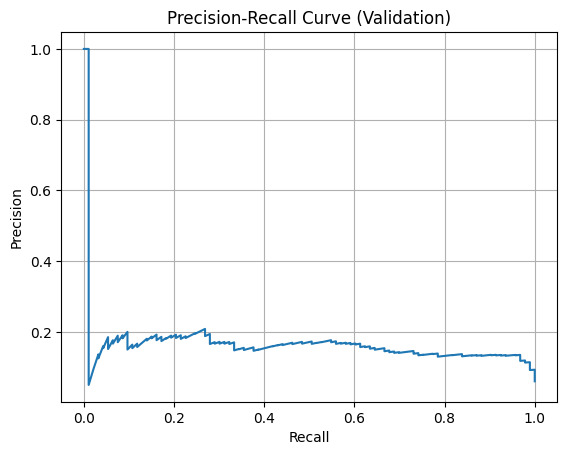

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_val, y_val_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Validation)")
plt.grid(True)
plt.show()

Risk-Based Claim Prioritization

9) Precision@K (Top-K evaluation)

In [ ]:
import numpy as np

def precision_at_k(y_true, y_prob, k):
    # y_true: array-like of 0/1
    # y_prob: predicted probabilities for class 1
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    # get indices of top k probs
    top_k_idx = np.argsort(y_prob)[::-1][:k]
    return y_true[top_k_idx].mean()

# Example: precision at top 100 flagged claims
print("Precision@100:", precision_at_k(y_val, y_val_prob, 100))

# Example: precision at top 5% of validation set
k_5pct = int(0.05 * len(y_val))
print("Precision@top 5%:", precision_at_k(y_val, y_val_prob, k_5pct))
print("k used:", k_5pct)

Precision@100: 0.19
Precision@top 5%: 0.18181818181818182
k used: 77


10) Create triage buckets (Approve / Manual Review / SIU)

In [ ]:
import pandas as pd
import numpy as np

val_results = X_val.copy()
val_results["y_true"] = y_val.values
val_results["risk_score"] = y_val_prob

# Sort by risk (highest first)
val_results = val_results.sort_values("risk_score", ascending=False).reset_index(drop=True)

# Define triage policy (change these numbers as needed)
pct_siu = 0.05        # top 5% -> SIU
pct_manual = 0.15     # next 15% -> Manual Review

n = len(val_results)
siu_cut = int(pct_siu * n)
manual_cut = int((pct_siu + pct_manual) * n)

def assign_bucket(i):
    if i < siu_cut:
        return "SIU"
    elif i < manual_cut:
        return "Manual Review"
    else:
        return "Approve"

val_results["triage_bucket"] = [assign_bucket(i) for i in range(n)]

# Show bucket counts
print(val_results["triage_bucket"].value_counts())

# Fraud rate inside each bucket (very important)
fraud_rate_by_bucket = val_results.groupby("triage_bucket")["y_true"].mean().sort_index()
print("\nFraud rate by bucket:")
print(fraud_rate_by_bucket)

triage_bucket
Approve          1234
Manual Review     231
SIU                77
Name: count, dtype: int64

Fraud rate by bucket:
triage_bucket
Approve          0.033225
Manual Review    0.164502
SIU              0.181818
Name: y_true, dtype: float64


11) Plot risk score distribution

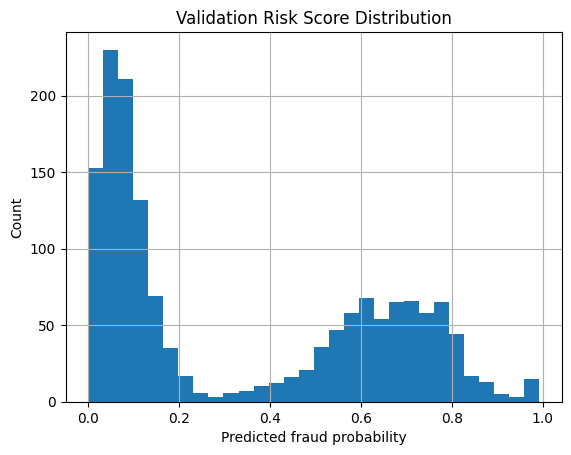

In [ ]:
plt.figure()
plt.hist(val_results["risk_score"], bins=30)
plt.title("Validation Risk Score Distribution")
plt.xlabel("Predicted fraud probability")
plt.ylabel("Count")
plt.grid(True)
plt.show()

12) compute precision@k and recall@k across k, plot, and choose K

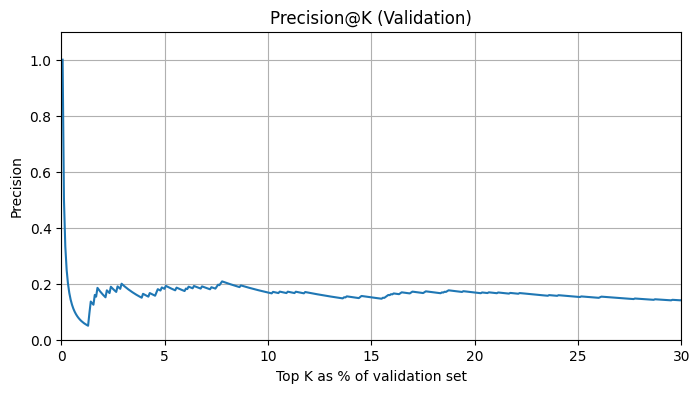

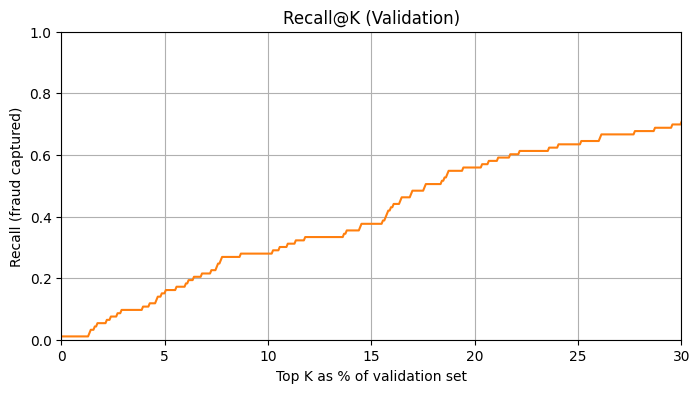

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Arrays
y_true = np.array(y_val)
y_prob = np.array(y_val_prob)
n = len(y_true)

# Sort descending by prob
order = np.argsort(y_prob)[::-1]
y_sorted = y_true[order]
p_sorted = y_prob[order]

# Precision@k and Recall@k arrays for k=1..n
prec_at_k = np.cumsum(y_sorted) / (np.arange(n) + 1)
rec_at_k = np.cumsum(y_sorted) / y_true.sum()

# Convert to percent-of-dataset (k_percent)
k_idx = np.arange(1, n+1)
k_pct = k_idx / n * 100

# Plot Precision@K and Recall@K vs % of dataset reviewed
plt.figure(figsize=(8,4))
plt.plot(k_pct, prec_at_k, label="Precision@K")
plt.xlabel("Top K as % of validation set")
plt.ylabel("Precision")
plt.title("Precision@K (Validation)")
plt.grid(True)
plt.xlim(0, 30)   # zoom into first 30% (typical review budget)
plt.ylim(0, max(prec_at_k[:int(0.3*n)])*1.1)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(k_pct, rec_at_k, label="Recall@K", color="C1")
plt.xlabel("Top K as % of validation set")
plt.ylabel("Recall (fraud captured)")
plt.title("Recall@K (Validation)")
plt.grid(True)
plt.xlim(0, 30)
plt.ylim(0, 1)
plt.show()

13) Useful summary table of selected % levels

In [ ]:
# helper to print metrics at given pct levels
def summary_at_pcts(pcts=[1,2,5,10,20]):
    print("pct\tk\tprecision\trecall\tk_count")
    for pct in pcts:
        k = int(np.round(pct/100 * n))
        if k < 1: k = 1
        prec = prec_at_k[k-1]
        rec = rec_at_k[k-1]
        print(f"{pct:2d}%\t{k:4d}\t{prec:.3f}\t\t{rec:.3f}\t{k}")

summary_at_pcts([1,2,5,10,20])

pct	k	precision	recall	k_count
 1%	  15	0.067		0.011	15
 2%	  31	0.161		0.054	31
 5%	  77	0.182		0.151	77
10%	 154	0.169		0.280	154
20%	 308	0.169		0.559	308


In [ ]:
def recall_at_k(y_true, y_prob, k):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    top_k_idx = np.argsort(y_prob)[::-1][:k]
    return y_true[top_k_idx].sum() / y_true.sum()

print("Recall@100:", recall_at_k(y_val, y_val_prob, 100))
print("Recall@top 5%:", recall_at_k(y_val, y_val_prob, k_5pct))

Recall@100: 0.20430107526881722
Recall@top 5%: 0.15053763440860216


In [ ]:
print("========== BASELINE SUMMARY ==========")
print(f"Fraud rate (validation): {y_val.mean():.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
print(f"Precision@5%: {precision_at_k(y_val, y_val_prob, k_5pct):.4f}")
print(f"Recall@5%: {recall_at_k(y_val, y_val_prob, k_5pct):.4f}")
print("=======================================")

========== BASELINE SUMMARY ==========
Fraud rate (validation): 0.0603
PR-AUC: 0.1677
Precision@5%: 0.1818
Recall@5%: 0.1505


In [ ]:
print(f"Enrichment (SIU vs Base Rate): {0.1818 / y_val.mean():.2f}x")

Enrichment (SIU vs Base Rate): 3.01x


In [ ]:
%pip install -q xgboost lightgbm

In [ ]:
import xgboost as xgb
import lightgbm as lgb

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report
)

# Rebuilding same preprocessing logic for xgboost and lightgbm so that models remain self contained
cat_cols_gbm = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols_gbm = X_train.select_dtypes(include=[np.number]).columns.tolist()

numeric_transformer_gbm = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_gbm = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_gbm = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_gbm, num_cols_gbm),
        ("cat", categorical_transformer_gbm, cat_cols_gbm),
    ],
    remainder="drop"
)

# Fitting preprocessor on train only, transforming val/test
X_train_gbm = preprocessor_gbm.fit_transform(X_train)
X_val_gbm   = preprocessor_gbm.transform(X_val)
X_test_gbm  = preprocessor_gbm.transform(X_test)

# Class imbalance helper
pos = int((y_train == 1).sum())
neg = int((y_train == 0).sum())
scale_pos_weight = neg / max(pos, 1)

print("Transformed train shape:", X_train_gbm.shape)
print("Transformed val shape:  ", X_val_gbm.shape)
print("Transformed test shape: ", X_test_gbm.shape)
print("scale_pos_weight:", round(scale_pos_weight, 4))

Transformed train shape: (12336, 148)
Transformed val shape:   (1542, 148)
Transformed test shape:  (1542, 148)
scale_pos_weight: 15.7154


Evaluation helper

In [ ]:
def evaluate_probs(y_true, y_prob, model_name="Model", pct_review=0.05):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    pr_auc = average_precision_score(y_true, y_prob)

    k = max(1, int(pct_review * len(y_true)))
    prec_k = precision_at_k(y_true, y_prob, k)
    rec_k = recall_at_k(y_true, y_prob, k)

    y_pred_05 = (y_prob >= 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred_05)

    print(f"========== {model_name.upper()} ==========")
    print(f"PR-AUC: {pr_auc:.4f}")
    print(f"Precision@5%: {prec_k:.4f}")
    print(f"Recall@5%: {rec_k:.4f}")
    print("Confusion Matrix @ 0.5:")
    print(cm)
    print("\nClassification Report @ 0.5:\n")
    print(classification_report(y_true, y_pred_05, digits=4))

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    plt.figure()
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve ({model_name})")
    plt.grid(True)
    plt.show()

    return {
        "Model": model_name,
        "PR_AUC": pr_auc,
        "Precision_at_5pct": prec_k,
        "Recall_at_5pct": rec_k
    }

========== XGBOOST ==========
PR-AUC: 0.7166
Precision@5%: 0.6883
Recall@5%: 0.5699
Confusion Matrix @ 0.5:
[[1407   42]
 [  22   71]]

Classification Report @ 0.5:

              precision    recall  f1-score   support

           0     0.9846    0.9710    0.9778      1449
           1     0.6283    0.7634    0.6893        93

    accuracy                         0.9585      1542
   macro avg     0.8065    0.8672    0.8335      1542
weighted avg     0.9631    0.9585    0.9604      1542



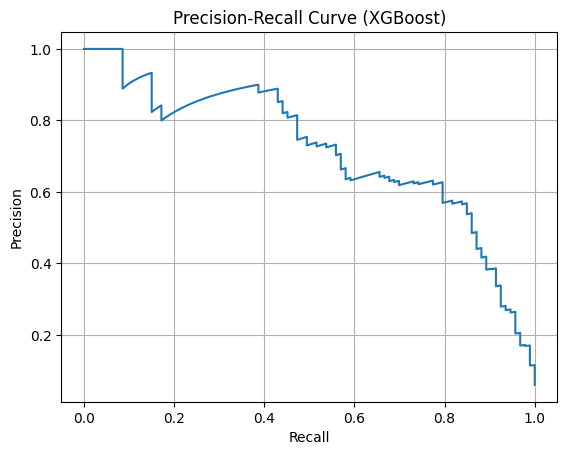

{'Model': 'XGBoost',
 'PR_AUC': np.float64(0.7165698204033683),
 'Precision_at_5pct': np.float64(0.6883116883116883),
 'Recall_at_5pct': np.float64(0.5698924731182796)}

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=1000,          # high upper limit; early stopping to find best round . high value of n_estimators used as an upper limit. early_stopping_rounds=50 used so that XGBoost can stop automatically at best boosting round to improve generalization and avoid unnecessary training time.
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    early_stopping_rounds=50
)

xgb_model.fit(
    X_train_gbm, y_train,
    eval_set=[(X_val_gbm, y_val)],
    verbose=False
)

xgb_val_prob = xgb_model.predict_proba(X_val_gbm)[:, 1]
xgb_summary = evaluate_probs(y_val, xgb_val_prob, model_name="XGBoost")
xgb_summary

[LightGBM] [Info] Number of positive: 738, number of negative: 11598
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.048224 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 609
[LightGBM] [Info] Number of data points in the train set: 12336, number of used features: 130
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.059825 -> initscore=-2.754644
[LightGBM] [Info] Start training from score -2.754644
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[2]	valid_0's average_precision: 0.242211	valid_0's binary_logloss: 0.20622
========== LIGHTGBM ==========
PR-AUC: 0.2422
Precision@5%: 0.3117
Recall@5%: 0.2581
Confusion Matrix @ 0.5:
[[1449    0]
 [  93    0]]

Classification Report @ 0.5:

              precision    recall  f1-score   support

           0     0.9397    1.0000    0.9689      1449
           1     0.0000    0.0000    0.0000        93

    a

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predict

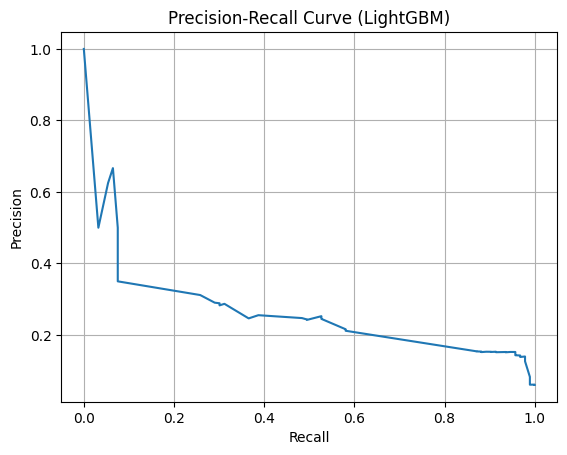

{'Model': 'LightGBM',
 'PR_AUC': np.float64(0.24221133303005965),
 'Precision_at_5pct': np.float64(0.3116883116883117),
 'Recall_at_5pct': np.float64(0.25806451612903225)}

In [ ]:
lgbm_model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

lgbm_model.fit(
    X_train_gbm, y_train,
    eval_set=[(X_val_gbm, y_val)],
    eval_metric="average_precision",
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=0)
    ]
)

lgbm_val_prob = lgbm_model.predict_proba(X_val_gbm)[:, 1]
lgbm_summary = evaluate_probs(y_val, lgbm_val_prob, model_name="LightGBM")
lgbm_summary

Baseline comparision for xgboost and lightgbm

In [ ]:
comparison_df = pd.DataFrame([
    {
        "Model": "Logistic Regression (baseline)",
        "PR_AUC": pr_auc,
        "Precision_at_5pct": precision_at_k(y_val, y_val_prob, max(1, int(0.05 * len(y_val)))),
        "Recall_at_5pct": recall_at_k(y_val, y_val_prob, max(1, int(0.05 * len(y_val))))
    },
    xgb_summary,
    lgbm_summary
]).sort_values("PR_AUC", ascending=False)

comparison_df

,Model,PR_AUC,Precision_at_5pct,Recall_at_5pct
1,XGBoost,0.716570,0.688312,0.569892
2,LightGBM,0.242211,0.311688,0.258065
0,Logistic Regression (baseline),0.167686,0.181818,0.150538


Triage buckets for better boosting model <br>
Picks the better GBM model on validation PR-AUC

In [ ]:

gbm_candidates = {
    "XGBoost": xgb_val_prob,
    "LightGBM": lgbm_val_prob
}

best_gbm_name = max(
    [("XGBoost", xgb_summary["PR_AUC"]), ("LightGBM", lgbm_summary["PR_AUC"])],
    key=lambda x: x[1]
)[0]

best_gbm_val_prob = gbm_candidates[best_gbm_name]

best_val_results = X_val.copy()
best_val_results["y_true"] = y_val.values
best_val_results["risk_score"] = best_gbm_val_prob

best_val_results = best_val_results.sort_values("risk_score", ascending=False).reset_index(drop=True)

pct_siu = 0.05
pct_manual = 0.15

n_best = len(best_val_results)
siu_cut_best = int(pct_siu * n_best)
manual_cut_best = int((pct_siu + pct_manual) * n_best)

def assign_bucket_best(i):
    if i < siu_cut_best:
        return "SIU"
    elif i < manual_cut_best:
        return "Manual Review"
    else:
        return "Approve"

best_val_results["triage_bucket"] = [assign_bucket_best(i) for i in range(n_best)]

print("Best GBM model:", best_gbm_name)
print("\nBucket counts:")
print(best_val_results["triage_bucket"].value_counts())

print("\nFraud rate by bucket:")
print(best_val_results.groupby("triage_bucket")["y_true"].mean().sort_index())

Best GBM model: XGBoost

Bucket counts:
triage_bucket
Approve          1234
Manual Review     231
SIU                77
Name: count, dtype: int64

Fraud rate by bucket:
triage_bucket
Approve          0.005673
Manual Review    0.142857
SIU              0.688312
Name: y_true, dtype: float64


========== XGBOOST (TEST) ==========
PR-AUC: 0.7926
Precision@5%: 0.7662
Recall@5%: 0.6413
Confusion Matrix @ 0.5:
[[1395   55]
 [  12   80]]

Classification Report @ 0.5:

              precision    recall  f1-score   support

           0     0.9915    0.9621    0.9765      1450
           1     0.5926    0.8696    0.7048        92

    accuracy                         0.9565      1542
   macro avg     0.7920    0.9158    0.8407      1542
weighted avg     0.9677    0.9565    0.9603      1542



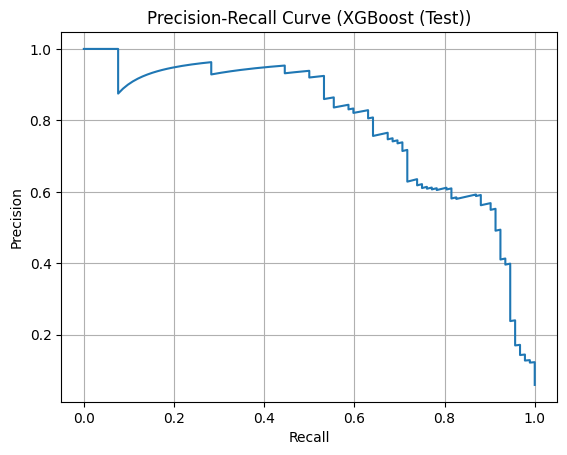

{'Model': 'XGBoost (Test)',
 'PR_AUC': np.float64(0.7926492568056174),
 'Precision_at_5pct': np.float64(0.7662337662337663),
 'Recall_at_5pct': np.float64(0.6413043478260869)}

In [ ]:
# Final evaluation on the held-out test set
best_model = xgb_model if best_gbm_name == "XGBoost" else lgbm_model
best_test_prob = best_model.predict_proba(X_test_gbm)[:, 1]

test_summary = evaluate_probs(y_test, best_test_prob, model_name=f"{best_gbm_name} (Test)")
test_summary